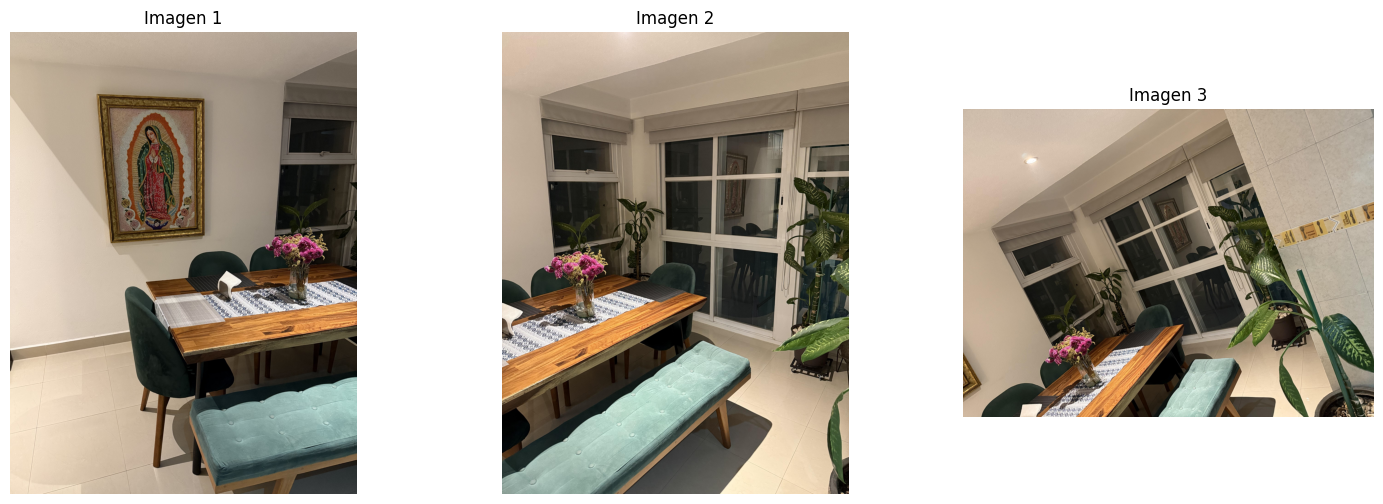

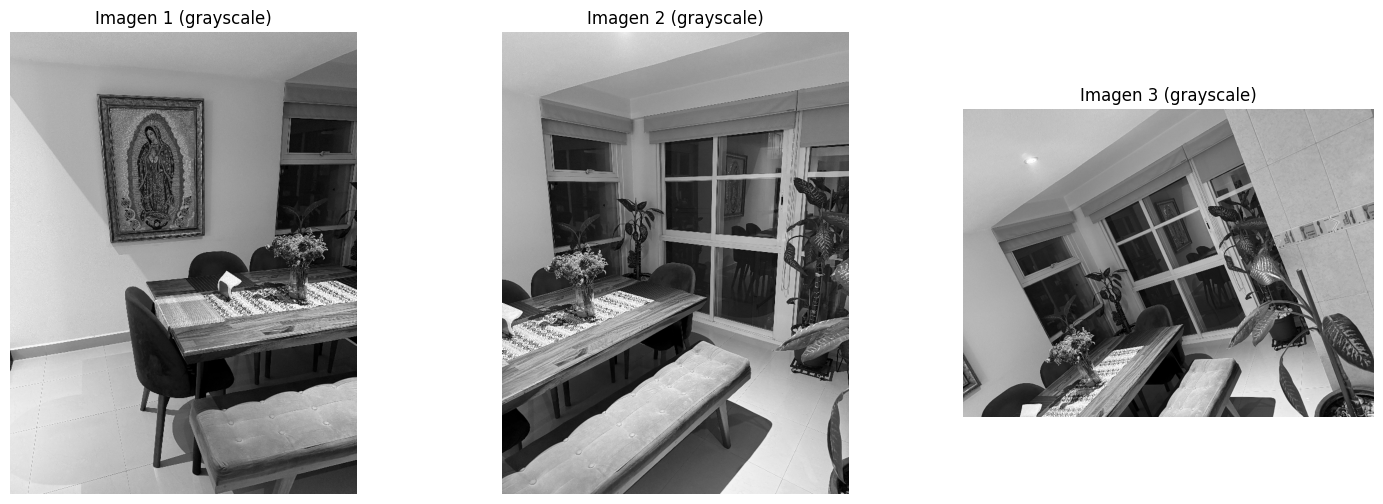

In [ ]:

import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# Rutas de las imágenes (ajusta si las descargas localmente)
img_paths = [
    "/content/IMG01.jpg",
    "/content/IMG02.jpg",
    "/content/IMG03.jpg"
]

# Cargar imágenes en color (BGR → RGB)
images = [cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB) for p in img_paths]

# Mostrar las imágenes originales
plt.figure(figsize=(18,6))
for i, img in enumerate(images):
    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(f"Imagen {i+1}")
    plt.axis('off')
plt.show()

# ---- PREPROCESAMIENTO ----
# 1. Redimensionar para reducir tiempos de cálculo
# 2. Ecualizar iluminación si es necesario

resized_images = []
for img in images:
    h, w = img.shape[:2]
    scale = 800 / max(h, w)   # Escala para ajustar la imagen más grande a 800 px
    img_resized = cv2.resize(img, (int(w*scale), int(h*scale)))
    resized_images.append(img_resized)

# Conversión a escala de grises para AKAZE
gray_images = [cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) for img in resized_images]

plt.figure(figsize=(18,6))
for i, g in enumerate(gray_images):
    plt.subplot(1,3,i+1)
    plt.imshow(g, cmap='gray')
    plt.title(f"Imagen {i+1} (grayscale)")
    plt.axis('off')
plt.show()

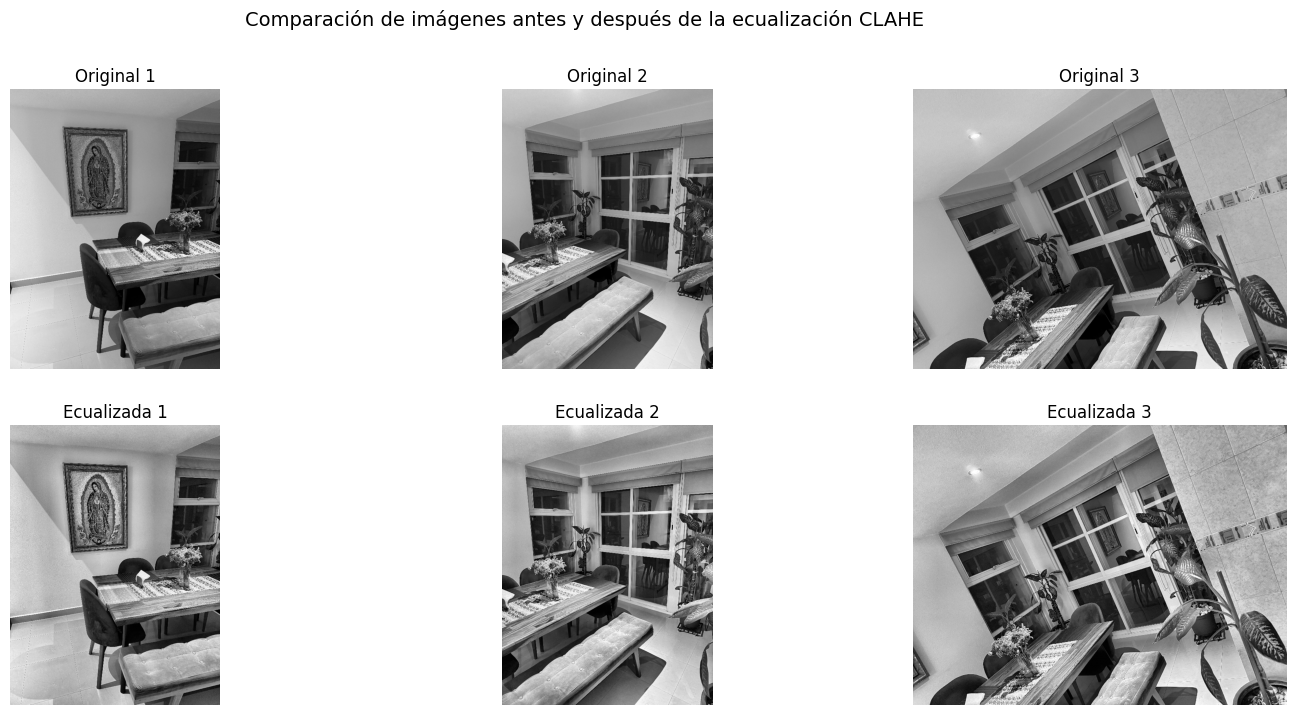

In [ ]:
# --- Ecualización del histograma (CLAHE) ---
# CLAHE (Contrast Limited Adaptive Histogram Equalization)
# mejora el contraste local sin saturar zonas brillantes u oscuras.

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
equalized_images = [clahe.apply(g) for g in gray_images]

# Visualizar comparación
plt.figure(figsize=(18,8))
for i in range(3):
    plt.subplot(2,3,i+1)
    plt.imshow(gray_images[i], cmap='gray')
    plt.title(f"Original {i+1}")
    plt.axis('off')

    plt.subplot(2,3,i+4)
    plt.imshow(equalized_images[i], cmap='gray')
    plt.title(f"Ecualizada {i+1}")
    plt.axis('off')

plt.suptitle("Comparación de imágenes antes y después de la ecualización CLAHE", fontsize=14)
plt.show()

# Opcional: normalizar intensidades a rango [0,255] para uniformar iluminación
normalized_images = [cv2.normalize(eq, None, 0, 255, cv2.NORM_MINMAX) for eq in equalized_images]


Puntos válidos (IMG1-IMG2): 58, (IMG2-IMG3): 226


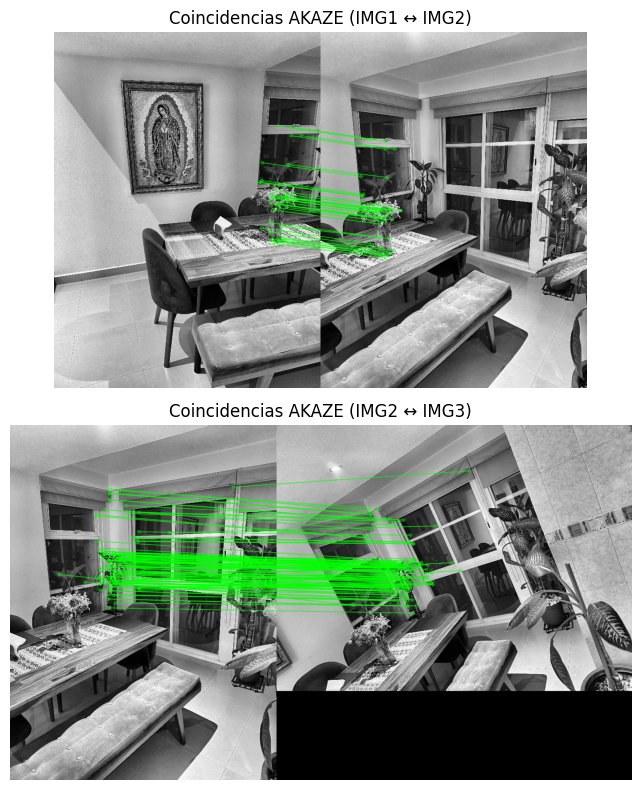

In [ ]:
# --- Configuración de parámetros ---
flann_index_kdtree = 1
index_params = dict(algorithm=flann_index_kdtree, trees=5)
search_params = dict(checks=50)  # Aumenta checks para mejorar correspondencias

# Crear el detector AKAZE
akaze = cv2.AKAZE_create()

# Función auxiliar para emparejar y estimar homografía
def match_and_homography(img1, img2):
    # Detectar y describir características
    kp1, des1 = akaze.detectAndCompute(img1, None)
    kp2, des2 = akaze.detectAndCompute(img2, None)

    # Convertir descriptores a float32 para FLANN
    des1 = np.float32(des1)
    des2 = np.float32(des2)

    # Emparejamiento con FLANN (usa distancia L2)
    flann = cv2.FlannBasedMatcher(index_params, search_params)
    matches = flann.knnMatch(des1, des2, k=2)

    # --- Ratio Test (Lowe) ---
    good_matches = []
    for m, n in matches:
        if m.distance < 0.7 * n.distance:
            good_matches.append(m)

    if len(good_matches) < 4:
        print("❌ Pocas coincidencias válidas para estimar la homografía.")
        return None, None, 0

    # Extraer puntos correspondientes
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1,1,2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1,1,2)

    # --- Estimar homografía con RANSAC ---
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 2.0)
    matches_mask = mask.ravel().tolist() if mask is not None else None

    # Dibujar coincidencias válidas
    img_matches = cv2.drawMatches(
        img1, kp1, img2, kp2, good_matches, None,
        matchColor=(0,255,0), singlePointColor=(255,0,0),
        matchesMask=matches_mask,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    return M, img_matches, len(good_matches)


# --- Emparejar IMG1 con IMG2, y luego con IMG3 ---
M12, matches12, n12 = match_and_homography(normalized_images[0], normalized_images[1])
M23, matches23, n23 = match_and_homography(normalized_images[1], normalized_images[2])

print(f"Puntos válidos (IMG1-IMG2): {n12}, (IMG2-IMG3): {n23}")

plt.figure(figsize=(16,8))
plt.subplot(2,1,1)
plt.imshow(matches12)
plt.title("Coincidencias AKAZE (IMG1 ↔ IMG2)")
plt.axis('off')

plt.subplot(2,1,2)
plt.imshow(matches23)
plt.title("Coincidencias AKAZE (IMG2 ↔ IMG3)")
plt.axis('off')
plt.tight_layout()
plt.show()

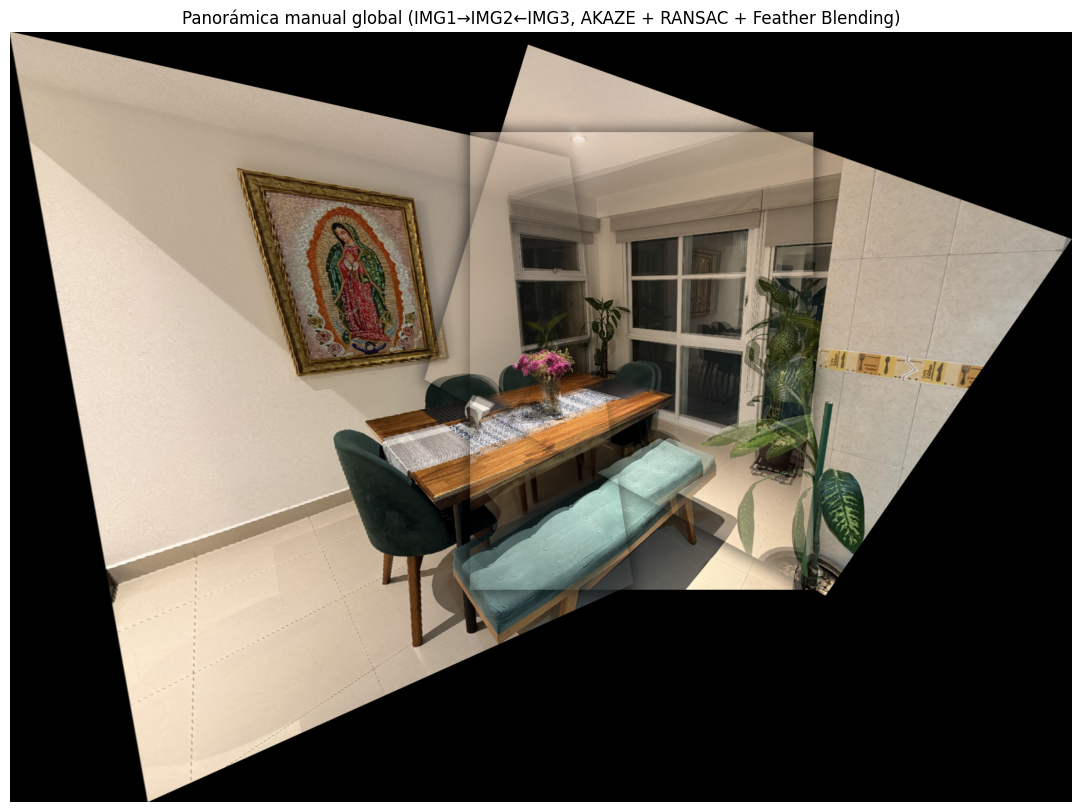

In [ ]:

# --- 2️⃣  Llevar todo al espacio de IMG2 ---
# H_1_to_global  =  M12   (IMG1→IMG2)
# H_3_to_global  =  inv(M23)   (IMG3→IMG2)
H1 = M12
H2 = np.eye(3)
H3 = np.linalg.inv(M23)

# --- 3️⃣  Calcular límites globales (para tamaño del lienzo) ---
def corners_in_global(img, H):
    h, w = img.shape[:2]
    corners = np.float32([[0,0],[0,h],[w,h],[w,0]]).reshape(-1,1,2)
    warped = cv2.perspectiveTransform(corners, H)
    return warped

corners_all = np.vstack([
    corners_in_global(resized_images[0], H1),
    corners_in_global(resized_images[1], H2),
    corners_in_global(resized_images[2], H3)
])

[xmin, ymin] = np.int32(corners_all.min(axis=0).ravel() - 0.5)
[xmax, ymax] = np.int32(corners_all.max(axis=0).ravel() + 0.5)
tx, ty = -xmin, -ymin
width, height = xmax - xmin, ymax - ymin

T = np.array([[1,0,tx],[0,1,ty],[0,0,1]])   # traslación común

# --- 4️⃣  Proyectar las tres imágenes al mismo lienzo ---
canvas = np.zeros((height, width, 3), dtype=np.float32)
weight = np.zeros((height, width, 3), dtype=np.float32)

def add_to_canvas(img, H):
    warped = cv2.warpPerspective(img, T @ H, (width, height))
    mask = (cv2.cvtColor(warped, cv2.COLOR_RGB2GRAY) > 0).astype(np.float32)
    mask = cv2.GaussianBlur(mask, (81,81), 0)
    mask3 = cv2.merge([mask,mask,mask])
    global canvas, weight
    canvas += warped.astype(np.float32) * mask3
    weight += mask3

# Acumular cada imagen
add_to_canvas(resized_images[0], H1)
add_to_canvas(resized_images[1], H2)
add_to_canvas(resized_images[2], H3)

# --- 5️⃣  Normalizar y mostrar ---
weight[weight == 0] = 1
panorama_manual = np.clip(canvas / weight, 0, 255).astype(np.uint8)

plt.figure(figsize=(20,10))
plt.imshow(panorama_manual)
plt.title("Panorámica manual global (IMG1→IMG2←IMG3, AKAZE + RANSAC + Feather Blending)")
plt.axis('off')
plt.show()

In [ ]:
# ==========================================================
# 🔧 BLOQUE — Refinamiento ECC (Enhanced Correlation Coefficient)
# ==========================================================
def ecc_refine_pair(fixed, moving, H_init, iterations=300, eps=1e-6):
    """
    Ajusta la homografía H_init para maximizar la correlación (ECC)
    entre la imagen fija (fixed) y la imagen móvil (moving).
    """
    H = H_init.copy().astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, iterations, eps)
    try:
        cc, H_refined = cv2.findTransformECC(
            fixed, moving, H, cv2.MOTION_HOMOGRAPHY, criteria
        )
        print(f"✅ ECC convergió con coeficiente {cc:.4f}")
        return H_refined
    except cv2.error as e:
        print("⚠️ ECC falló:", e)
        return H

# Refinar IMG1→IMG2
H12_ecc = ecc_refine_pair(normalized_images[1], normalized_images[0], M12)

# Refinar IMG3→IMG2 (OJO: usamos inv(M23))
H32_ecc = ecc_refine_pair(normalized_images[1], normalized_images[2], np.linalg.inv(M23))


⚠️ ECC falló: OpenCV(4.12.0) /io/opencv/modules/video/src/ecc.cpp:589: error: (-7:Iterations do not converge) The algorithm stopped before its convergence. The correlation is going to be minimized. Images may be uncorrelated or non-overlapped in function 'findTransformECC'

✅ ECC convergió con coeficiente 0.2646


In [ ]:
H1 = H12_ecc
H2 = np.eye(3)
H3 = H32_ecc

canvas_ecc = np.zeros((height, width, 3), dtype=np.float32)
weight_ecc = np.zeros((height, width, 3), dtype=np.float32)

def add_to_canvas(img, H):
    warped = cv2.warpPerspective(img, T @ H, (width, height))
    mask = (cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY) > 0).astype(np.float32)
    mask = cv2.GaussianBlur(mask, (81,81), 0)
    mask3 = cv2.merge([mask,mask,mask])
    global canvas_ecc, weight_ecc
    canvas_ecc += warped.astype(np.float32) * mask3
    weight_ecc += mask3

add_to_canvas(resized_images[0], H1)
add_to_canvas(resized_images[1], H2)
add_to_canvas(resized_images[2], H3)

weight_ecc[weight_ecc == 0] = 1
panorama_ecc = np.clip(canvas_ecc / weight_ecc, 0, 255).astype(np.uint8)


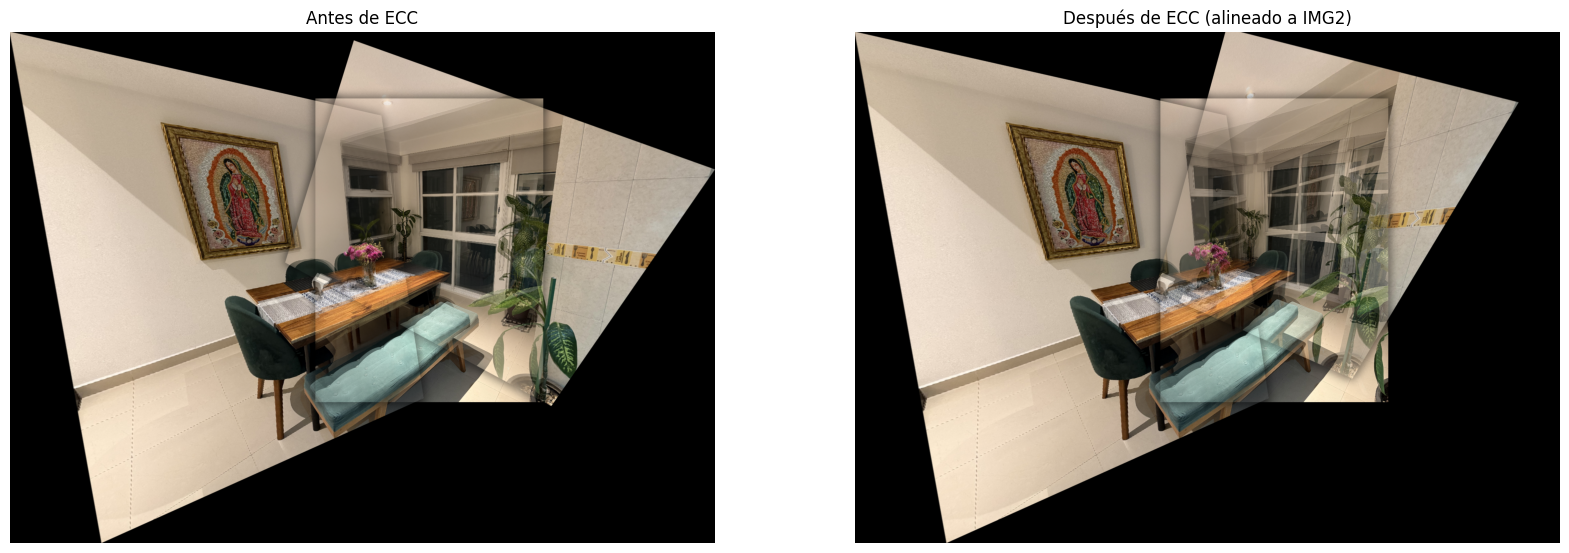

In [ ]:
plt.figure(figsize=(20,10))
plt.subplot(1,2,1)
plt.imshow(panorama_manual)
plt.title("Antes de ECC")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(panorama_ecc)
plt.title("Después de ECC (alineado a IMG2)")
plt.axis('off')
plt.show()


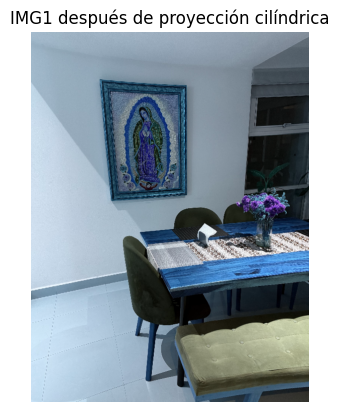

In [ ]:
import numpy as np, cv2

def cylindrical_projection(img, f):
    """
    Aplica proyección cilíndrica a una imagen dada una distancia focal f.
    f se puede estimar como (ancho_img / 2) / tan(FOV/2)
    """
    h, w = img.shape[:2]
    K = np.array([[f, 0, w/2],
                  [0, f, h/2],
                  [0, 0, 1]], dtype=np.float32)

    # Crear malla de coordenadas
    y_i, x_i = np.indices((h, w))
    X = (x_i - w/2) / f
    Y = (y_i - h/2) / f
    Z = np.sqrt(X**2 + 1)

    x_ = np.arctan(X)
    y_ = Y / Z

    x_map = f * x_ + w/2
    y_map = f * y_ + h/2

    cylindrical = cv2.remap(img, x_map.astype(np.float32), y_map.astype(np.float32),
                            interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)
    return cylindrical

# --- Aplicar solo a la imagen que lo necesita ---
focal = 800  # ajusta según tu cámara (~ancho_px / 2.3)
resized_images[0] = cylindrical_projection(resized_images[0], focal)  # ejemplo: solo IMG1
# resized_images[2] = cylindrical_projection(resized_images[2], focal)  # si prefieres solo IMG3

plt.imshow(cv2.cvtColor(resized_images[0], cv2.COLOR_BGR2RGB))
plt.title("IMG1 después de proyección cilíndrica")
plt.axis('off')
plt.show()
